# Used Car Price Prediction (CarDekho)

**Goal:** predict the resale `selling_price` (INR) of a used car from its brand, age, kilometres driven, fuel type, seller type, transmission and ownership history.

**Workflow:** data ingestion → cleaning & feature engineering → EDA → train/test split → model comparison → tuning → evaluation → summary → export for the Streamlit app (`app.py`).

## 1. Data ingestion

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)
RANDOM_STATE = 42
CURRENT_YEAR = 2026   # reference year used to turn `year` into `car_age`

In [2]:
# Put the CSV next to this notebook (or change the path).
DATA_PATH = "CAR_DETAILS_FROM_CAR_DEKHO.csv"
df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (4340, 8)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB


In [4]:
# Quick health check: missing values, duplicates, cardinality of each column
print("Missing values per column:\n", df_raw.isna().sum(), "\n")
print("Exact duplicate rows:", df_raw.duplicated().sum())
print("Unique values per column:\n", df_raw.nunique())
df_raw.describe()

Missing values per column:
 name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64 

Exact duplicate rows: 763
Unique values per column:
 name             1491
year               27
selling_price     445
km_driven         770
fuel                5
seller_type         3
transmission        2
owner               5
dtype: int64


,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


## 2. Preprocessing and feature engineering

Decisions made here:

* **Drop exact duplicate rows.** Keeping them would let the same car appear in both train and test sets and inflate the scores.
* **`year` → `car_age`** (`CURRENT_YEAR - year`): age relates to price more directly than a calendar year.
* **`name` → `brand`**: the full name has ~1,500 unique values (model + trim), far too sparse to encode. The first word is the make.
* **Remove physically implausible `km_driven`** values (> 500,000 km).
* **Log-transform `selling_price`**: the price is heavily right-skewed, and errors are better measured in relative terms.
* **Rare categories** (Electric/LPG/CNG fuel, "Test Drive Car" owner, small brands) are grouped *inside* the model pipeline with `OneHotEncoder(min_frequency=...)`, so the grouping is learned from the training set only.

In [5]:
df = df_raw.drop_duplicates().reset_index(drop=True)
print(f"Rows after dropping duplicates: {len(df)} (removed {len(df_raw) - len(df)})")

# --- feature engineering ---
df["car_age"] = CURRENT_YEAR - df["year"]
df["brand"] = (df["name"].str.split().str[0]
                         .replace({"Land": "Land Rover", "OpelCorsa": "Opel"}))

# --- outliers in km_driven ---
print("Rows with km_driven > 500,000:", (df["km_driven"] > 500_000).sum())
df = df[df["km_driven"] <= 500_000].reset_index(drop=True)

# --- target transformation ---
df["log_price"] = np.log1p(df["selling_price"])

print("Final shape:", df.shape)
print("\nBrand counts:\n", df["brand"].value_counts().to_string())
df.head()

Rows after dropping duplicates: 3577 (removed 763)
Rows with km_driven > 500,000: 2
Final shape: (3575, 11)

Brand counts:
 brand
Maruti           1070
Hyundai           637
Mahindra          328
Tata              308
Ford              220
Honda             216
Toyota            170
Chevrolet         151
Renault           110
Volkswagen         93
Nissan             52
Skoda              49
Fiat               32
Audi               31
Datsun             29
BMW                25
Mercedes-Benz      21
Jaguar              5
Mitsubishi          5
Land Rover          5
Volvo               4
Jeep                3
Ambassador          3
MG                  2
Opel                2
Daewoo              1
Force               1
Isuzu               1
Kia                 1


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age,brand,log_price
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,19,Maruti,11.002117
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,19,Maruti,11.813037
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,14,Hyundai,13.304687
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,9,Datsun,12.429220
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,12,Honda,13.017005


## 3. Exploratory data analysis

### 3.1 Univariate analysis

Skewness  price: 5.45 | log price: -0.02


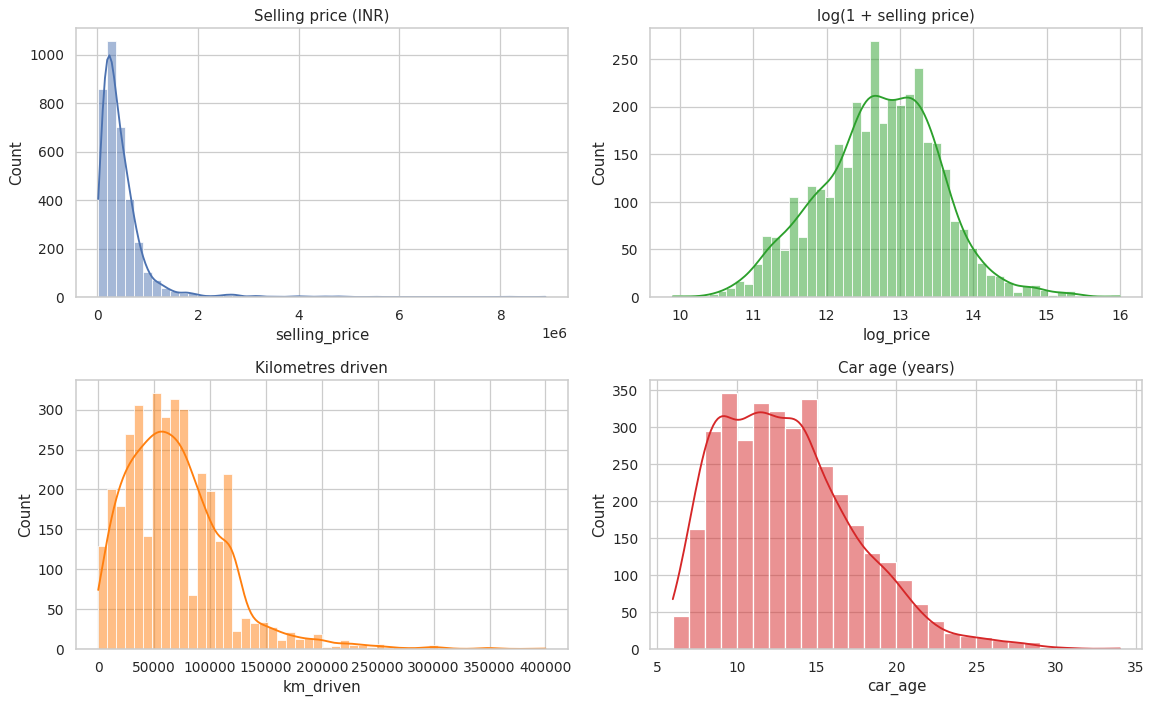

In [6]:
# The raw price is strongly right-skewed (a few very expensive cars); the log makes it close to bell-shaped.
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
sns.histplot(df["selling_price"], bins=50, kde=True, ax=axes[0, 0]).set(title="Selling price (INR)")
sns.histplot(df["log_price"], bins=50, kde=True, ax=axes[0, 1], color="tab:green").set(title="log(1 + selling price)")
sns.histplot(df["km_driven"], bins=50, kde=True, ax=axes[1, 0], color="tab:orange").set(title="Kilometres driven")
sns.histplot(df["car_age"], bins=28, kde=True, ax=axes[1, 1], color="tab:red").set(title="Car age (years)")
plt.tight_layout(); plt.show()
print("Skewness  price: %.2f | log price: %.2f" % (df["selling_price"].skew(), df["log_price"].skew()))

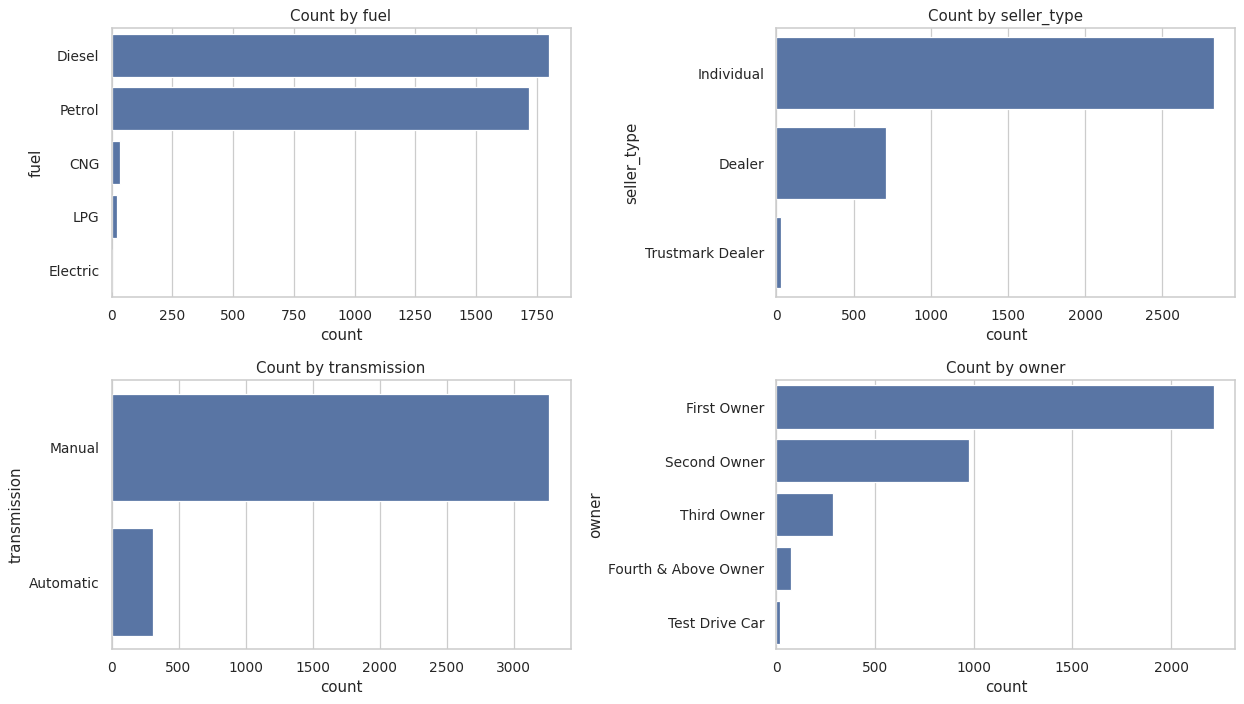

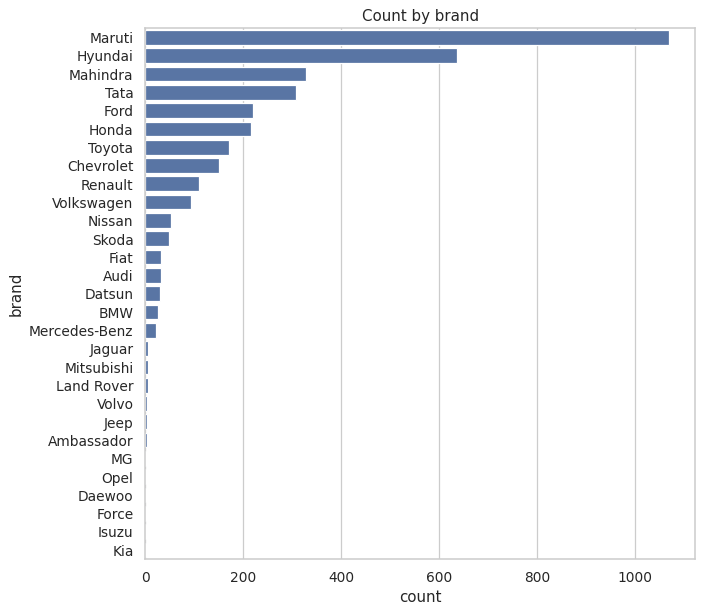

In [7]:
# Counts of every categorical column. Note how unbalanced they are:
# few automatics, few CNG/LPG/Electric cars, very few 'Test Drive' cars.
cat_cols = ["fuel", "seller_type", "transmission", "owner"]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.ravel(), cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax)
    ax.set_title(f"Count by {col}")
plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 7))
sns.countplot(data=df, y="brand", order=df["brand"].value_counts().index)
plt.title("Count by brand"); plt.tight_layout(); plt.show()

### 3.2 Bivariate analysis

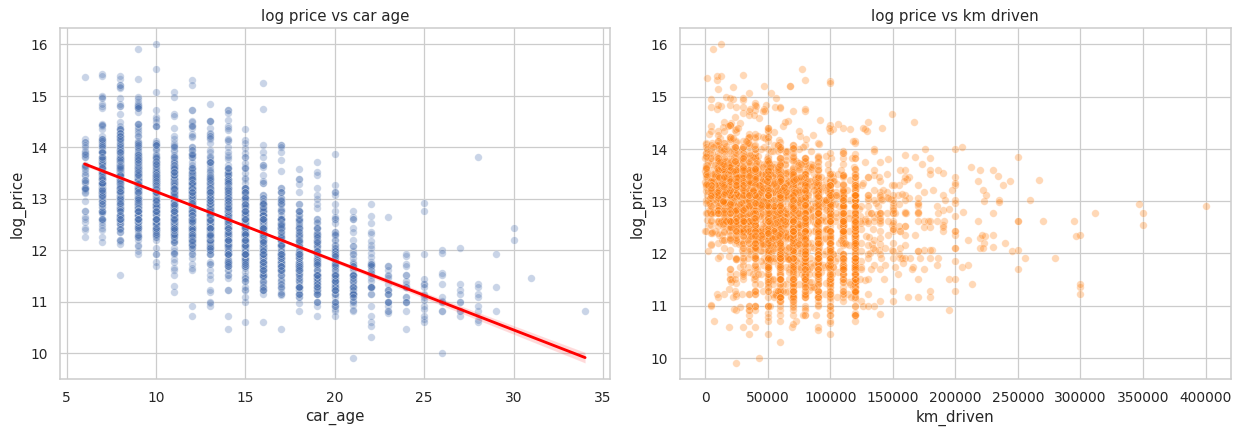

In [8]:
# Price vs the two numeric drivers. Price falls steeply with age and (less cleanly) with mileage.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="car_age", y="log_price", alpha=0.3, ax=axes[0])
sns.regplot(data=df, x="car_age", y="log_price", scatter=False, color="red", ax=axes[0])
axes[0].set_title("log price vs car age")
sns.scatterplot(data=df, x="km_driven", y="log_price", alpha=0.3, ax=axes[1], color="tab:orange")
axes[1].set_title("log price vs km driven")
plt.tight_layout(); plt.show()

          count    median
fuel                     
LPG          22  180000.0
CNG          37  229999.0
Petrol     1716  260000.0
Electric      1  310000.0
Diesel     1799  475000.0 

                  count    median
seller_type                      
Individual         2832  303500.0
Dealer              710  484999.0
Trustmark Dealer     33  750000.0 

              count    median
transmission                 
Manual         3263  325000.0
Automatic       312  855000.0 

                      count    median
owner                                
Fourth & Above Owner     75  138000.0
Third Owner             289  190000.0
Second Owner            978  267000.0
First Owner            2216  450000.0
Test Drive Car           17  894999.0 



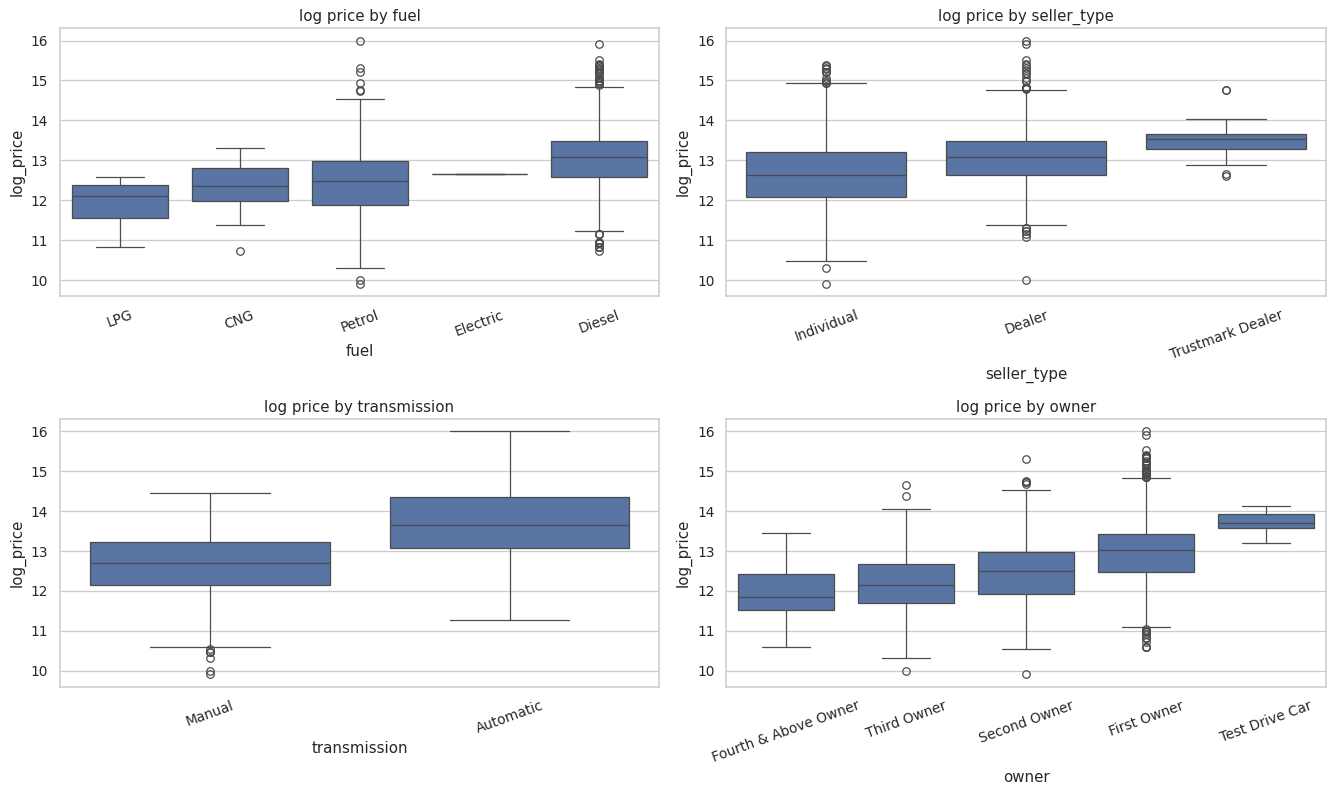

In [9]:
# Price distribution across each categorical feature
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    order = df.groupby(col)["log_price"].median().sort_values().index
    sns.boxplot(data=df, x=col, y="log_price", order=order, ax=ax)
    ax.set_title(f"log price by {col}")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

# Median price in rupees, easier to read than the log values
for col in cat_cols:
    print(df.groupby(col)["selling_price"].agg(["count", "median"]).sort_values("median").round(0), "\n")

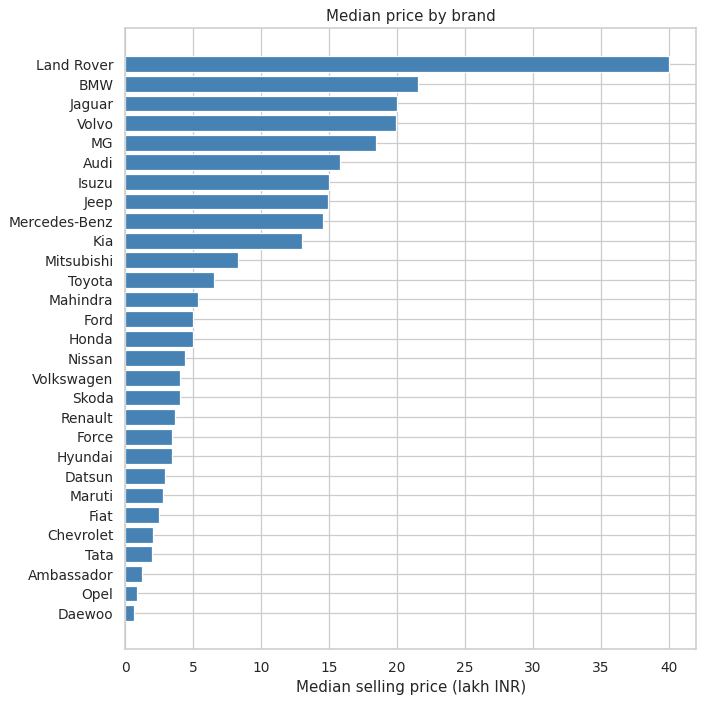

In [10]:
# Average (median) price by brand: luxury makes (BMW, Audi, Mercedes, Jaguar, Land Rover...) sit far above mass-market ones.
brand_stats = df.groupby("brand")["selling_price"].agg(["count", "median"]).sort_values("median")
plt.figure(figsize=(8, 8))
plt.barh(brand_stats.index, brand_stats["median"] / 1e5, color="steelblue")
plt.xlabel("Median selling price (lakh INR)"); plt.title("Median price by brand")
plt.tight_layout(); plt.show()

### 3.3 Multivariate analysis

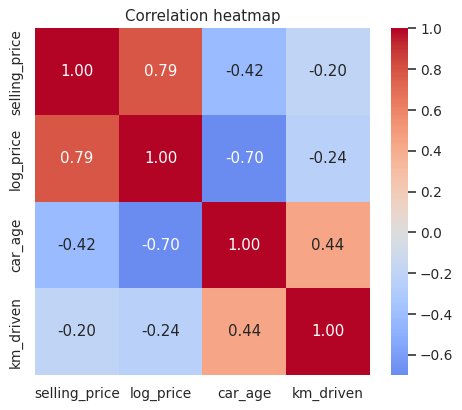

In [11]:
# Correlations between numeric variables. Age is the strongest (negative) correlate of price.
num_df = df[["selling_price", "log_price", "car_age", "km_driven"]]
plt.figure(figsize=(6, 5))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap"); plt.show()

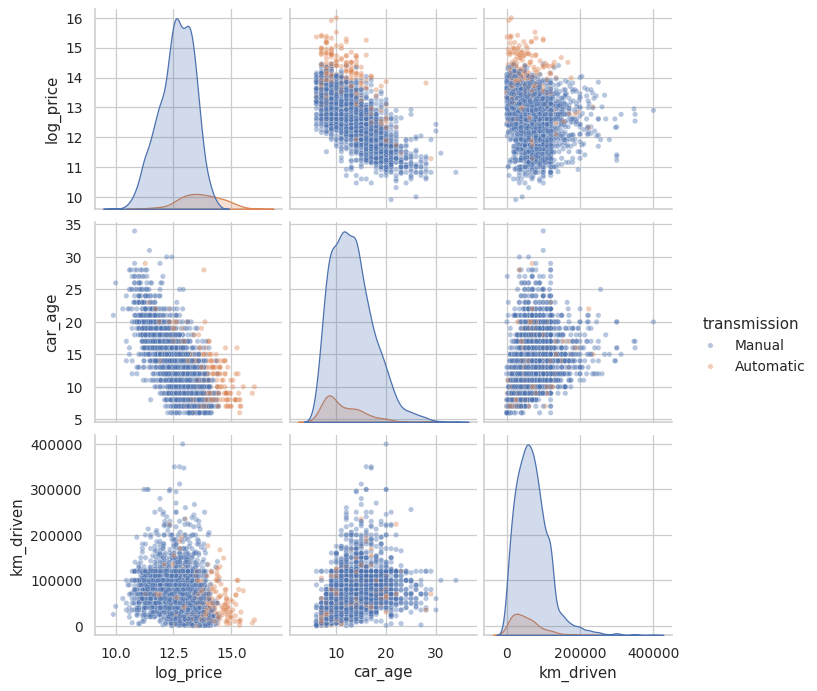

In [12]:
# Pairplot coloured by transmission; automatics sit at the high-price end at every age.
sns.pairplot(df[["log_price", "car_age", "km_driven", "transmission"]],
             hue="transmission", plot_kws={"alpha": 0.4, "s": 18}, height=2.6)
plt.show()

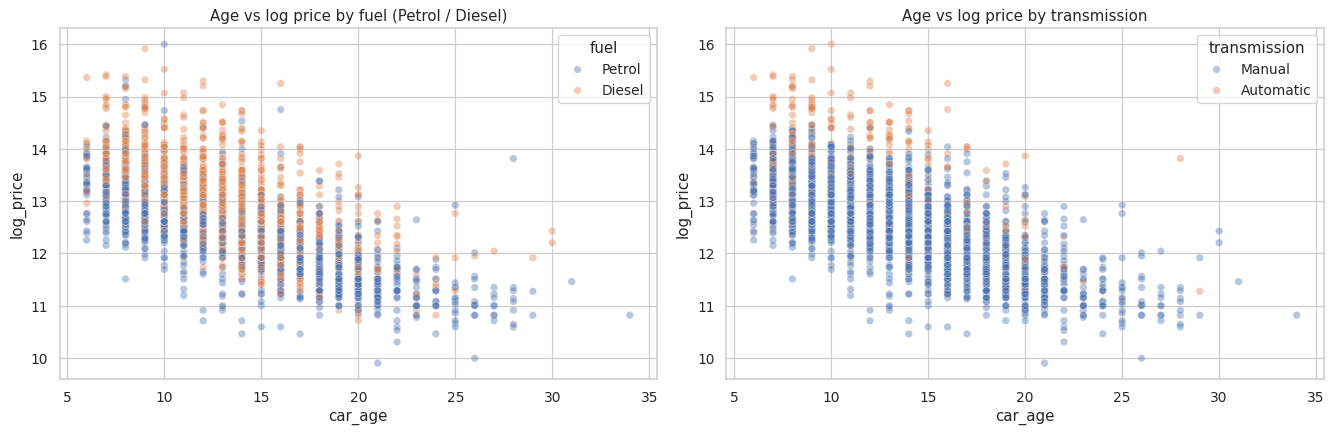

In [13]:
# Does the age-price relationship differ by fuel type and by transmission?
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=df[df["fuel"].isin(["Petrol", "Diesel"])], x="car_age", y="log_price", hue="fuel", alpha=0.4, ax=axes[0])
axes[0].set_title("Age vs log price by fuel (Petrol / Diesel)")
sns.scatterplot(data=df, x="car_age", y="log_price", hue="transmission", alpha=0.4, ax=axes[1])
axes[1].set_title("Age vs log price by transmission")
plt.tight_layout(); plt.show()

### 3.4 Outlier checks

IQR outliers  price: 170 | log price: 29 | km_driven: 104


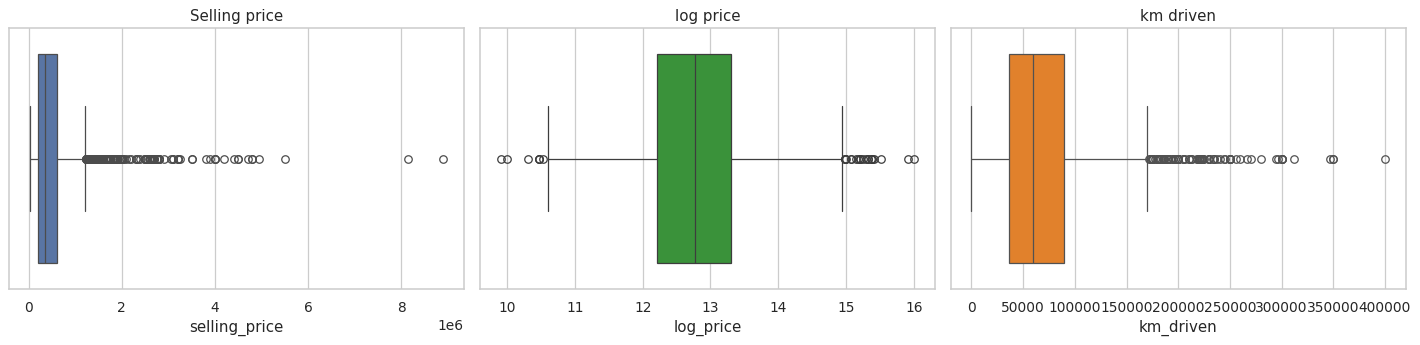

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(x=df["selling_price"], ax=axes[0]).set(title="Selling price")
sns.boxplot(x=df["log_price"], ax=axes[1], color="tab:green").set(title="log price")
sns.boxplot(x=df["km_driven"], ax=axes[2], color="tab:orange").set(title="km driven")
plt.tight_layout(); plt.show()

def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()
print("IQR outliers  price: %d | log price: %d | km_driven: %d" %
      (iqr_outliers(df["selling_price"]), iqr_outliers(df["log_price"]), iqr_outliers(df["km_driven"])))
# The high prices are real luxury cars, not data errors, so they are kept; the log transform tames their influence.

**EDA takeaways**

* Price is right-skewed; log-transform fixes it.
* Newer cars are much more expensive; more km driven means lower price.
* Automatic, diesel, dealer-sold, first-owner and luxury-brand cars cost more.
* Several categories are very small (Electric, LPG, CNG, Test Drive Car, several brands), so they are grouped before modelling.

## 4. Train/test split and preprocessing pipeline

In [15]:
FEATURES = ["brand", "car_age", "km_driven", "fuel", "seller_type", "transmission", "owner"]
CAT_FEATURES = ["brand", "fuel", "seller_type", "transmission", "owner"]

X = df[FEATURES]
y = df["log_price"]                 # models are trained on log(1 + price)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "| Test:", X_test.shape)

def make_preprocessor():
    return ColumnTransformer([
        ("age", StandardScaler(), ["car_age"]),
        # km_driven is right-skewed, so log it before scaling
        ("km", Pipeline([("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                         ("scale", StandardScaler())]), ["km_driven"]),
        # categories with < 20 training rows are merged into one 'infrequent' bucket;
        # unseen categories at prediction time fall into that bucket instead of raising an error
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=20,
                              sparse_output=False), CAT_FEATURES),
    ])

def make_pipeline(model):
    return Pipeline([("prep", make_preprocessor()), ("model", model)])

Train: (2860, 7) | Test: (715, 7)


## 5. Build and compare regression models

All models share the same preprocessing pipeline, so scaling/encoding is fitted only on the training data in every fold of cross-validation (no leakage).

Metrics:
* **R² (log)**: R² on the log-price scale, the scale the models are trained on.
* **R² (INR), MAE, RMSE, MAPE**: after converting predictions back to rupees, so they are easy to interpret.

In [16]:
def regression_metrics(y_true_log, y_pred_log):
    yt, yp = np.expm1(y_true_log), np.expm1(y_pred_log)
    return {
        "R2_log": r2_score(y_true_log, y_pred_log),
        "R2_INR": r2_score(yt, yp),
        "MAE_INR": mean_absolute_error(yt, yp),
        "RMSE_INR": np.sqrt(mean_squared_error(yt, yp)),
        "MAPE_%": np.mean(np.abs(yt - yp) / yt) * 100,
    }

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=10000),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "KNN": KNeighborsRegressor(n_neighbors=7, weights="distance"),
    "SVR": SVR(C=10, epsilon=0.05),
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, model in models.items():
    pipe = make_pipeline(model)
    cv = cross_val_score(pipe, X_train, y_train, cv=kf, scoring="r2")     # 5-fold CV on the training set
    pipe.fit(X_train, y_train)
    row = {"Model": name,
           "CV R2_log (mean)": cv.mean(), "CV R2_log (std)": cv.std(),
           "Train R2_log": r2_score(y_train, pipe.predict(X_train))}
    row.update({f"Test {k}": v for k, v in regression_metrics(y_test, pipe.predict(X_test)).items()})
    rows.append(row)

results = pd.DataFrame(rows).set_index("Model").sort_values("CV R2_log (mean)", ascending=False)
results.round(3)

,CV R2_log (mean),CV R2_log (std),Train R2_log,Test R2_log,Test R2_INR,Test MAE_INR,Test RMSE_INR,Test MAPE_%
Model,,,,,,,,
Gradient Boosting,0.788,0.014,0.818,0.760,0.673,147074.513,322459.791,34.653
SVR,0.764,0.009,0.859,0.773,0.664,145785.917,327055.242,32.773
Ridge,0.762,0.020,0.781,0.757,0.651,151928.718,333359.952,35.545
Linear Regression,0.762,0.020,0.782,0.757,0.652,152255.886,332833.508,35.580
Lasso,0.761,0.019,0.780,0.756,0.645,151364.268,335960.447,35.515
Random Forest,0.754,0.014,0.950,0.741,0.660,153290.207,328929.307,34.986
KNN,0.727,0.013,0.977,0.703,0.551,158940.137,378114.315,36.600
Decision Tree,0.727,0.011,0.820,0.679,0.547,173860.850,379888.626,38.269


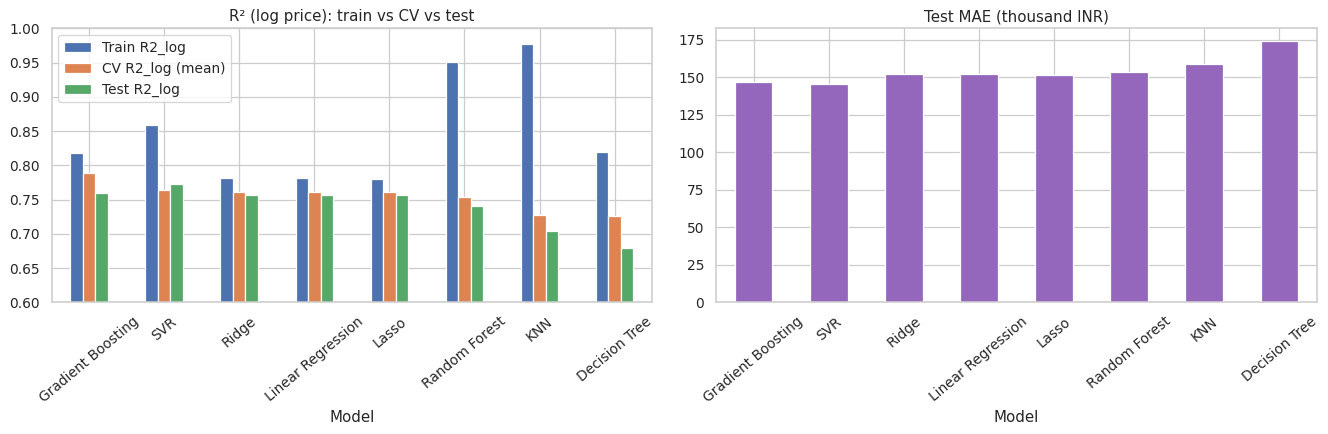

In [17]:
# Visual comparison + overfitting check (train R2 vs CV R2 vs test R2)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_df = results[["Train R2_log", "CV R2_log (mean)", "Test R2_log"]]
plot_df.plot(kind="bar", ax=axes[0]); axes[0].set_ylim(0.6, 1.0)
axes[0].set_title("R² (log price): train vs CV vs test"); axes[0].tick_params(axis="x", rotation=40)
(results["Test MAE_INR"] / 1e3).plot(kind="bar", ax=axes[1], color="tab:purple")
axes[1].set_title("Test MAE (thousand INR)"); axes[1].tick_params(axis="x", rotation=40)
plt.tight_layout(); plt.show()

## 6. Hyperparameter tuning and final evaluation

The two best tree-ensemble candidates are tuned with `RandomizedSearchCV` (5-fold CV on the **training set only**). The test set is used once, at the end.

In [18]:
searches = {
    "Gradient Boosting": (GradientBoostingRegressor(random_state=RANDOM_STATE), {
        "model__n_estimators": [200, 300, 500],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [3, 4, 5],
        "model__subsample": [0.7, 0.85, 1.0],
        "model__min_samples_leaf": [1, 3, 5, 10],
    }),
    "Random Forest": (RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1), {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 12, 18],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": [0.5, 0.8, 1.0],
    }),
}

tuned = {}
for name, (model, grid) in searches.items():
    rs = RandomizedSearchCV(make_pipeline(model), grid, n_iter=12, cv=kf, scoring="r2",
                            random_state=RANDOM_STATE, n_jobs=1)
    rs.fit(X_train, y_train)
    tuned[name] = rs
    print(f"{name}: best CV R2_log = {rs.best_score_:.4f}")
    print("   ", {k.replace('model__', ''): v for k, v in rs.best_params_.items()})

Gradient Boosting: best CV R2_log = 0.7919
    {'subsample': 0.7, 'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 4, 'learning_rate': 0.05}
Random Forest: best CV R2_log = 0.7804
    {'n_estimators': 300, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 12}


In [19]:
# Pick the winner by cross-validation score (not by test score) and evaluate it on the held-out test set once.
best_name = max(tuned, key=lambda n: tuned[n].best_score_)
best_pipe = tuned[best_name].best_estimator_
pred_log = best_pipe.predict(X_test)
final_metrics = regression_metrics(y_test, pred_log)
print("Selected model:", best_name)
pd.Series(final_metrics).round(3).to_frame("Test set")

Selected model: Gradient Boosting


,Test set
R2_log,0.774
R2_INR,0.633
MAE_INR,144629.376
RMSE_INR,341632.334
MAPE_%,32.920


### Diagnostics for the final model

Residual mean: -0.0208 | std: 0.3940


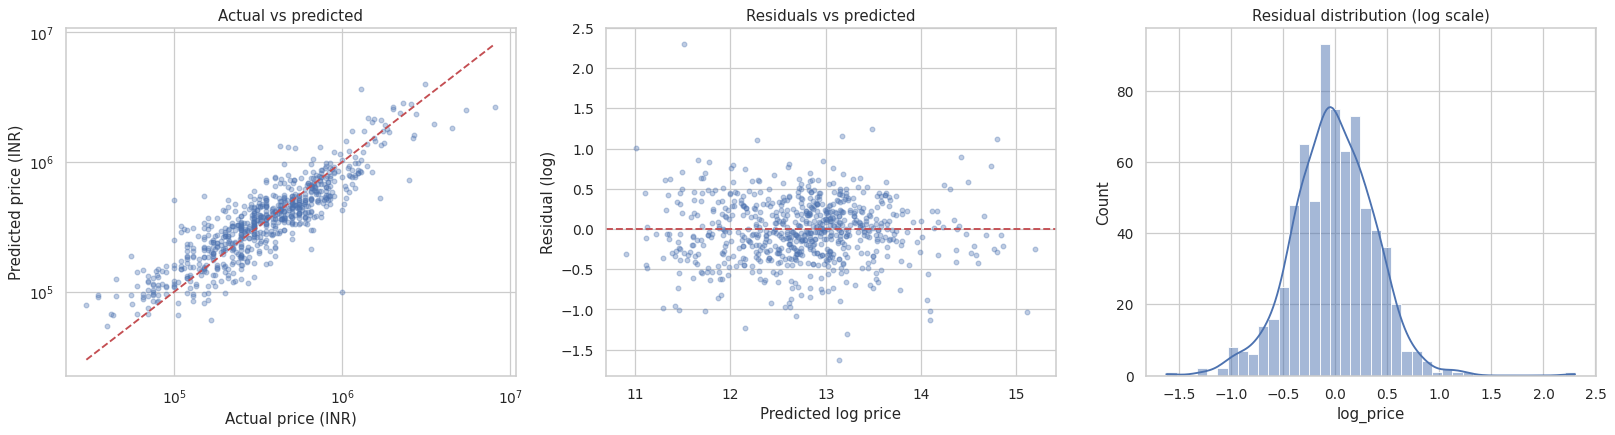

In [20]:
y_true_inr, y_pred_inr = np.expm1(y_test), np.expm1(pred_log)
resid_log = y_test - pred_log

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# 1) actual vs predicted (rupees, log axes so cheap and expensive cars are both visible)
axes[0].scatter(y_true_inr, y_pred_inr, alpha=0.35, s=14)
lims = [y_true_inr.min(), y_true_inr.max()]
axes[0].plot(lims, lims, "r--"); axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set(xlabel="Actual price (INR)", ylabel="Predicted price (INR)", title="Actual vs predicted")
# 2) residuals vs predicted (should be a patternless cloud around 0)
axes[1].scatter(pred_log, resid_log, alpha=0.35, s=14)
axes[1].axhline(0, color="r", ls="--")
axes[1].set(xlabel="Predicted log price", ylabel="Residual (log)", title="Residuals vs predicted")
# 3) residual distribution
sns.histplot(resid_log, bins=40, kde=True, ax=axes[2]); axes[2].set_title("Residual distribution (log scale)")
plt.tight_layout(); plt.show()
print("Residual mean: %.4f | std: %.4f" % (resid_log.mean(), resid_log.std()))

In [21]:
# Where does the model do well or badly? Median absolute % error by price band and by age band.
err = pd.DataFrame({"actual": y_true_inr, "pred": y_pred_inr, "age": X_test["car_age"]})
err["abs_pct_err"] = (err["actual"] - err["pred"]).abs() / err["actual"] * 100
err["price_band"] = pd.qcut(err["actual"], 5)
err["age_band"] = pd.cut(err["age"], [0, 5, 8, 11, 15, 40])
print(err.groupby("price_band", observed=True)["abs_pct_err"].median().round(1).to_frame("median abs % error"), "\n")
print(err.groupby("age_band", observed=True)["abs_pct_err"].median().round(1).to_frame("median abs % error"))

                       median abs % error
price_band                               
(29999.999, 170000.0]                39.0
(170000.0, 285000.0]                 25.7
(285000.0, 427600.0]                 20.2
(427600.0, 661000.0]                 18.6
(661000.0, 8150000.0]                23.8 

          median abs % error
age_band                    
(5, 8]                  18.6
(8, 11]                 21.2
(11, 15]                25.2
(15, 40]                30.7


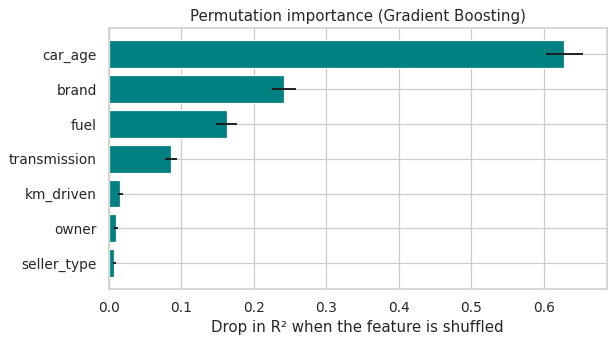

,importance
car_age,0.6283
brand,0.2420
fuel,0.1629
transmission,0.0860
km_driven,0.0161
owner,0.0097
seller_type,0.0075


In [22]:
# Feature importance via permutation on the test set (works on the raw input columns for any model).
pi = permutation_importance(best_pipe, X_test, y_test, n_repeats=15, random_state=RANDOM_STATE, scoring="r2")
imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values()
plt.figure(figsize=(7, 4))
plt.barh(imp.index, imp.values, xerr=pd.Series(pi.importances_std, index=X_test.columns)[imp.index], color="teal")
plt.xlabel("Drop in R² when the feature is shuffled"); plt.title(f"Permutation importance ({best_name})")
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(4).to_frame("importance")

## 7. Save the final model for the Streamlit app

In [23]:
# The deployed model is the tuned pipeline re-fitted on ALL cleaned data (more data for the final model).
# TransformedTargetRegressor applies log1p on training and expm1 on prediction,
# so model.predict() returns the price directly in INR.
final_model = TransformedTargetRegressor(regressor=clone(best_pipe), func=np.log1p, inverse_func=np.expm1)
final_model.fit(X, df["selling_price"])

joblib.dump(final_model, "car_price_model.pkl")

# Sanity check: reload and predict one example
reloaded = joblib.load("car_price_model.pkl")
example = pd.DataFrame([{"brand": "Maruti", "car_age": 8, "km_driven": 60000, "fuel": "Petrol",
                         "seller_type": "Individual", "transmission": "Manual", "owner": "First Owner"}])
print("Example prediction (8-year-old Maruti, 60,000 km): INR {:,.0f}".format(reloaded.predict(example)[0]))

Example prediction (8-year-old Maruti, 60,000 km): INR 387,678


## 8. Summary

**Data issues found and how they were handled**

| Issue | Handling |
|---|---|
| 763 exact duplicate rows (4,340 → 3,577) | Dropped before splitting, to avoid train/test leakage |
| `name` has 1,491 unique values | Reduced to `brand` (first word) |
| Heavily right-skewed price | Modelled `log(1 + price)`; predictions are converted back to INR |
| 2 cars with `km_driven` > 500,000 | Removed as implausible (3,575 rows remain) |
| Rare categories (1 Electric, 22 LPG, 37 CNG, 17 Test Drive Car, small brands) | Merged into an "infrequent" bucket in the encoder, learned from training data only |
| No missing values | Nothing to impute |

**Model comparison** (5-fold CV on the training set, then the 20% test set; see the table in section 5):
Gradient Boosting had the best cross-validated R² on log price (0.788). Linear models (Ridge, Lasso, plain regression) and SVR scored close behind (0.76). Random Forest and KNN overfit clearly (train R² 0.95 and 0.98 against test 0.74 and 0.70). The single Decision Tree was the weakest.

**Final model:** Gradient Boosting, tuned with `RandomizedSearchCV` (CV R² 0.792), which was marginally ahead of the tuned Random Forest (0.780). Chosen on CV score, not test score.

| Test metric | Value |
|---|---|
| R² (log price) | 0.774 |
| R² (INR) | 0.633 |
| MAE | about ₹1.45 lakh |
| RMSE | about ₹3.42 lakh |
| MAPE | about 33% |

Car age is by far the most important feature, followed by brand and fuel type. Mileage, owner and seller type add little once age and brand are known.

**Limitations**

* **Moderate accuracy.** A typical prediction is off by 19–26% for mid-priced cars and by about 39% for the cheapest cars (below ₹1.7 lakh), where small rupee gaps are large percentages. Older cars (15+ years) are also harder to price.
* **No car model or variant.** Only the brand is used, so a Swift and an 800 from the same make and year look alike. In a quick check on this split, using brand plus the first word of the model name raised log-R² from about 0.77 to 0.80. Adding a model dropdown is the most obvious next step.
* **Missing price drivers.** Condition, city, accidents and service history are not in the data.
* **Small groups are unreliable.** Electric, LPG, luxury brands and test-drive cars have very few examples.
* **Data is dated.** Cars are from 1992–2020 and `car_age` is measured against 2026, so predictions for newer cars are extrapolation. Prices also reflect the market when the data was collected, not today's.
* The deployed model is re-fitted on all cleaned data, so the test metrics above describe the train-only version.